In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

from scipy.stats import linregress
import DataProcessor

In [2]:
RUPTURE_POSITIONS = [105, 100, 95, 90, 85, 80, 75, 65, 55, 45, 35, 25, 15, 5]
NORMAL_STRESSES = [2.5, 5.0, 7.5, 10.0, 12.5]

G_AVERAGE = []
G_STD = []

In [3]:
for NORMAL_STRESS in NORMAL_STRESSES:
    folder_path = f"./NormalStress/{NORMAL_STRESS:.1f}MPa"

    spring_energies = []

    for RUPTURE_POSITION in RUPTURE_POSITIONS:
        
        filename = f'strain-energy-{RUPTURE_POSITION}.npz'
        file_path = os.path.join(folder_path, filename)
        if not os.path.exists(file_path):
            print(f"[WARNING] File {filename} not found. Skipping.")
            continue
        data = np.load(file_path)
        spring_energies.append(data.get('ELSE-Spring', np.nan))


    spring_energies = np.array(spring_energies)
    G_spring = -np.gradient(spring_energies, RUPTURE_POSITIONS)

    G_AVERAGE.append(np.mean(G_spring))
    G_STD.append(np.std(G_spring))

    plot_individual = False
    if plot_individual:

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

        ax1.plot(RUPTURE_POSITIONS, spring_energies, 's-', label='Spring Energy')
        ax1.set_ylabel('Strain Energy')
        ax1.set_title('Spring Energy vs. Rupture Position')
        ax1.grid(True)
        ax1.legend()
        ax2.plot(RUPTURE_POSITIONS, G_spring, 's-', label='Spring Energy Gradient', color='tab:orange')
        ax2.set_xlabel('Rupture Position (mm)')
        ax2.set_ylabel('Energy Gradient')
        ax2.set_title('Gradient of Spring Energy vs. Rupture Position')
        ax2.grid(True)
        ax2.legend()

        plt.tight_layout()
        plt.show()
        plt.close()


NORMAL_STRESSES = np.array(NORMAL_STRESSES)
G_AVERAGE = np.array(G_AVERAGE)
G_STD     = np.array(G_STD)

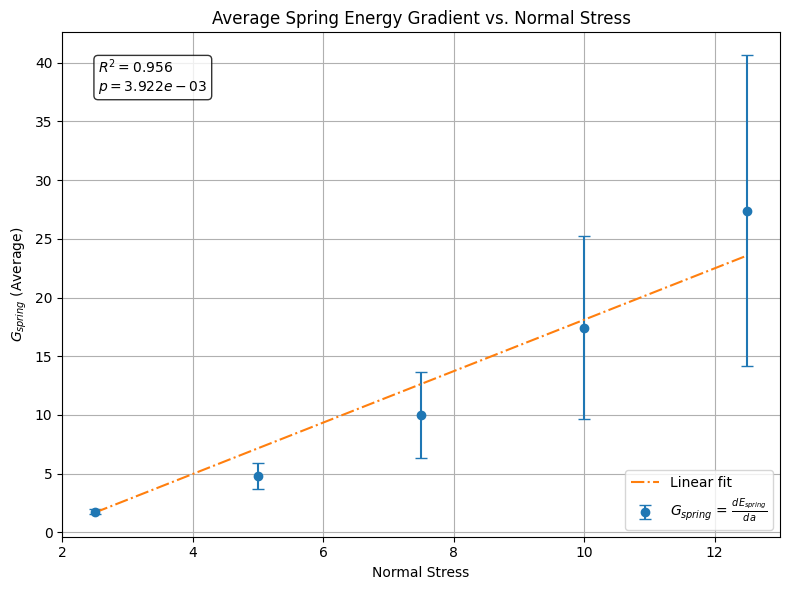

In [4]:
slope, intercept, r_value, p_value, std_err = linregress(NORMAL_STRESSES, G_AVERAGE)
slope, intercept = DataProcessor.get_linear_regression(NORMAL_STRESSES, G_AVERAGE, np.ones_like(NORMAL_STRESSES), G_STD, slope, intercept)

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(NORMAL_STRESSES, G_AVERAGE, yerr=G_STD, fmt='o', capsize=4, label=r'$G_{spring}$ = $\frac{dE_{spring}}{da}$')

x_fit = np.linspace(min(NORMAL_STRESSES), max(NORMAL_STRESSES), 100)
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, '-.', label='Linear fit')

r_squared = r_value**2
textstr = f'$R^2 = {r_squared:.3f}$\n$p = {p_value:.3e}$'
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Normal Stress')
ax.set_ylabel(r'$G_{spring}$ (Average)')
ax.legend()
ax.grid(True)
plt.title('Average Spring Energy Gradient vs. Normal Stress')
plt.tight_layout()
plt.savefig('./NormalStress/Plots/NormalStress-G.pdf', dpi=300)
plt.show()
plt.close()

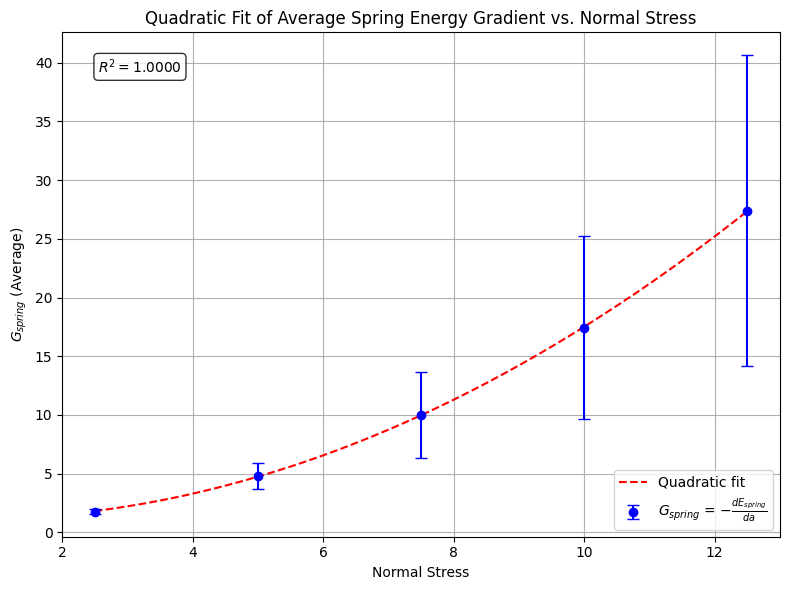

In [5]:

X = np.column_stack((NORMAL_STRESSES**2, NORMAL_STRESSES))
X = sm.add_constant(X)

model = sm.OLS(G_AVERAGE, X)
results = model.fit()
a, b, c = results.params[1], results.params[2], results.params[0]
r_squared = results.rsquared

x_fit = np.linspace(min(NORMAL_STRESSES), max(NORMAL_STRESSES), 200)
y_fit = a * x_fit**2 + b * x_fit + c

plt.figure(figsize=(8, 6))
plt.plot(x_fit, y_fit, 'r--', label='Quadratic fit')
# plt.scatter(NORMAL_STRESSES, G_AVERAGE, color='blue', label=r'$G_{spring}$ = $-\frac{dE_{spring}}{da}$')
plt.errorbar(NORMAL_STRESSES, G_AVERAGE, yerr=G_STD, color='blue', fmt='o', capsize=4, label=r'$G_{spring}$ = $-\frac{dE_{spring}}{da}$')


plt.text(0.05, 0.95, f'$R^2 = {r_squared:.4f}$', transform=plt.gca().transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.xlabel('Normal Stress')
plt.ylabel(r'$G_{spring}$ (Average)')
plt.title('Quadratic Fit of Average Spring Energy Gradient vs. Normal Stress')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('./NormalStress/Plots/NormalStress-G-Quadratic.pdf', dpi=300)
plt.show()